This assignment involves the use of simple linear regression on the `Auto` data set.

In [1]:
# Import your libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
auto = pd.read_csv('../data/Auto.csv', na_values='?')
auto = auto.dropna()
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [3]:
auto.shape

(392, 9)

**a) Use the sm.OLS() function to perform a simple linear regression
with `mpg` as the response and `horsepower` as the predictor. Use
the `summarize()` function to print the results. Comment on the
following:**

**i. Is there a relationship between the predictor and the response?**

**ii. How strong is the relationship between the predictor and
the response?**

**iii. Is the relationship between the predictor and the response
positive or negative?**

**iv. What is the predicted mpg associated with a horsepower of
98? What are the associated 95 % confidence and prediction
intervals?**

In [4]:
# use as many code cells as you need, but enter your comments in Markdown cells
model = sm.OLS(auto['mpg'], sm.add_constant((auto['horsepower'])))
results = model.fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 17 Sep 2025   Prob (F-statistic):           7.03e-81
Time:                        13:59:52   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

i) There is a relationship between horsepower and mpg because of the incredibly small p values.

ii) The relationship is somewhat strong with an R-squared of 0.606 meaning 60.6% of variability can be explained with this model

iii) The relationship appears to be a negative relationship as the horsepower coefficient is -0.1578.

iv) The predicted mpg of a car with 98 housepaower is 24.4715. 

In [5]:
print(39.9359 - 0.1578 * 98)

24.4715


**b) Plot the response and the predictor in a new set of axes `ax`. Use the `ax.axline()` method or the `abline()` function defined in the practice lab to display the least squares regression line.**

In [ ]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

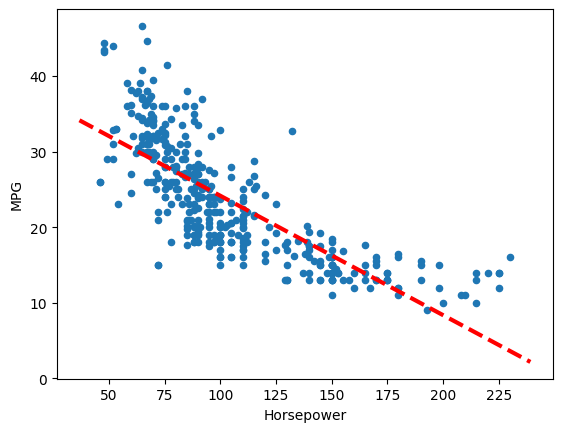

In [10]:
ax = auto.plot.scatter(x='horsepower', y='mpg')
abline(ax, 39.9359, -0.1578, 'r--', linewidth=3)
ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG')
plt.show()

**c) Produce some of diagnostic plots of the least squares regression
fit as described in the lab. Comment on any problems you see
with the fit.**

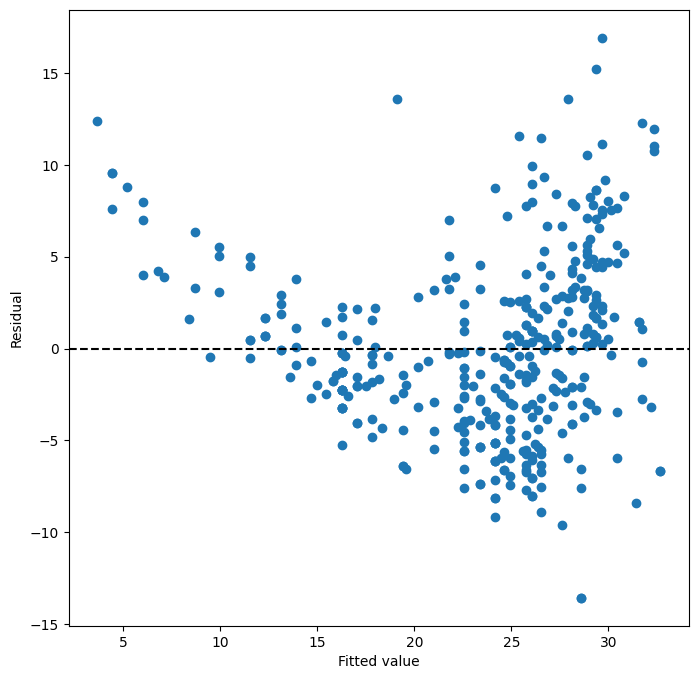

In [9]:
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

np.int64(115)

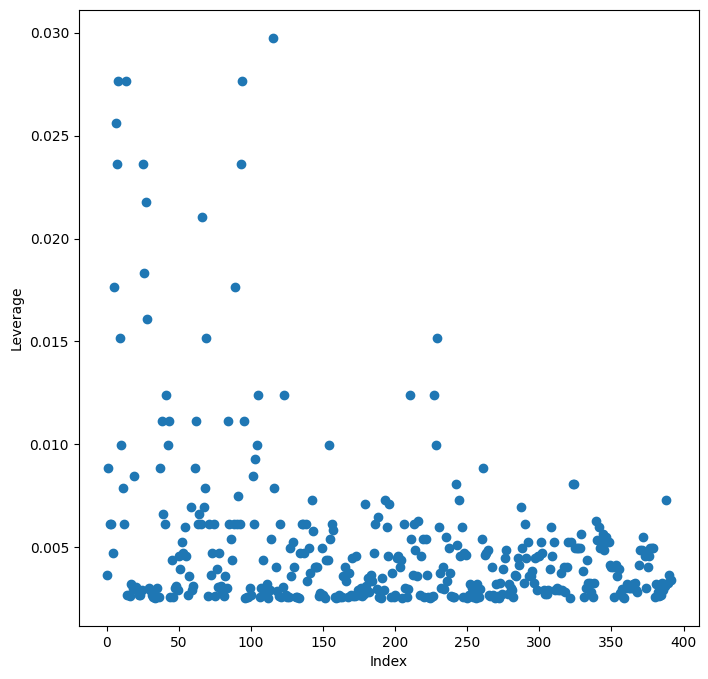

In [24]:
influence = results.get_influence()
ax = plt.subplots(figsize=(8,8))[1]
ax.scatter(np.arange(len(auto)), influence.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(influence.hat_matrix_diag)

In [27]:
print(auto.iloc[115])

mpg                           16.0
cylinders                        8
displacement                 400.0
horsepower                   230.0
weight                        4278
acceleration                   9.5
year                            73
origin                           1
name            pontiac grand prix
Name: 116, dtype: object
